In [3]:
# Load peristim matrix
from pathlib import Path
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

import RCP_analysis as rcp

# Paths
REPO_ROOT = Path().resolve().parents[0]
PARAMS = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)

SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
OUT_BASE.mkdir(parents=True, exist_ok=True)

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"

TARGET = 'Target_B'
FILES = 'peristim__NRR_RW011_251203_154933__BR_024_target_B.npz'

npz_path = PERI_ROOT / TARGET / FILES
peristim_npz = np.load(npz_path, allow_pickle=True)

In [4]:
NPRW_rel_t = peristim_npz['NPRW_rel_t']
NPRW_peak_ms_dedup = peristim_npz['NPRW_peak_ms_dedup']
NPRW_counts = peristim_npz['NPRW_counts']
NPRW_rates_zeroed = peristim_npz['NPRW_rates_zeroed']
# peristim_npz['stim_ms']

In [7]:
NPRW_rates_zeroed

array([[[ 1.34585309e+02,  1.29732045e+02,  2.35635628e+01, ...,
          1.63870451e+01, -6.44278129e+01, -8.57770471e+01],
        [ 5.71807261e+01,  1.19628414e+02,  6.71923913e+01, ...,
          6.49943683e+01, -1.22027732e+01, -7.21872154e+01],
        [ 3.82130595e+01, -8.37998612e+00, -7.83809733e+01, ...,
          3.27826388e+01, -3.40642819e+01, -9.31313293e+01],
        ...,
        [-1.24688887e+02, -5.65003186e+01,  2.00388410e+00, ...,
          1.05924858e+02,  1.20251377e+02,  3.47031166e+01],
        [-3.96897233e+01, -4.43516556e+01, -5.36854909e+01, ...,
          9.18019025e+01,  1.18461823e+02,  1.02008018e+02],
        [ 3.22992751e+01,  2.09030086e+01,  6.01258707e+01, ...,
         -1.73589861e+01, -2.23998298e+01, -3.57212105e+01]],

       [[ 2.35314465e+01,  2.50482558e+01,  7.03292138e+01, ...,
          6.68140832e+01,  3.55462620e+01,  2.03609364e+01],
        [-1.00946044e+02, -6.25292729e+01,  2.70139688e+01, ...,
          2.08605583e+02,  2.99267682e

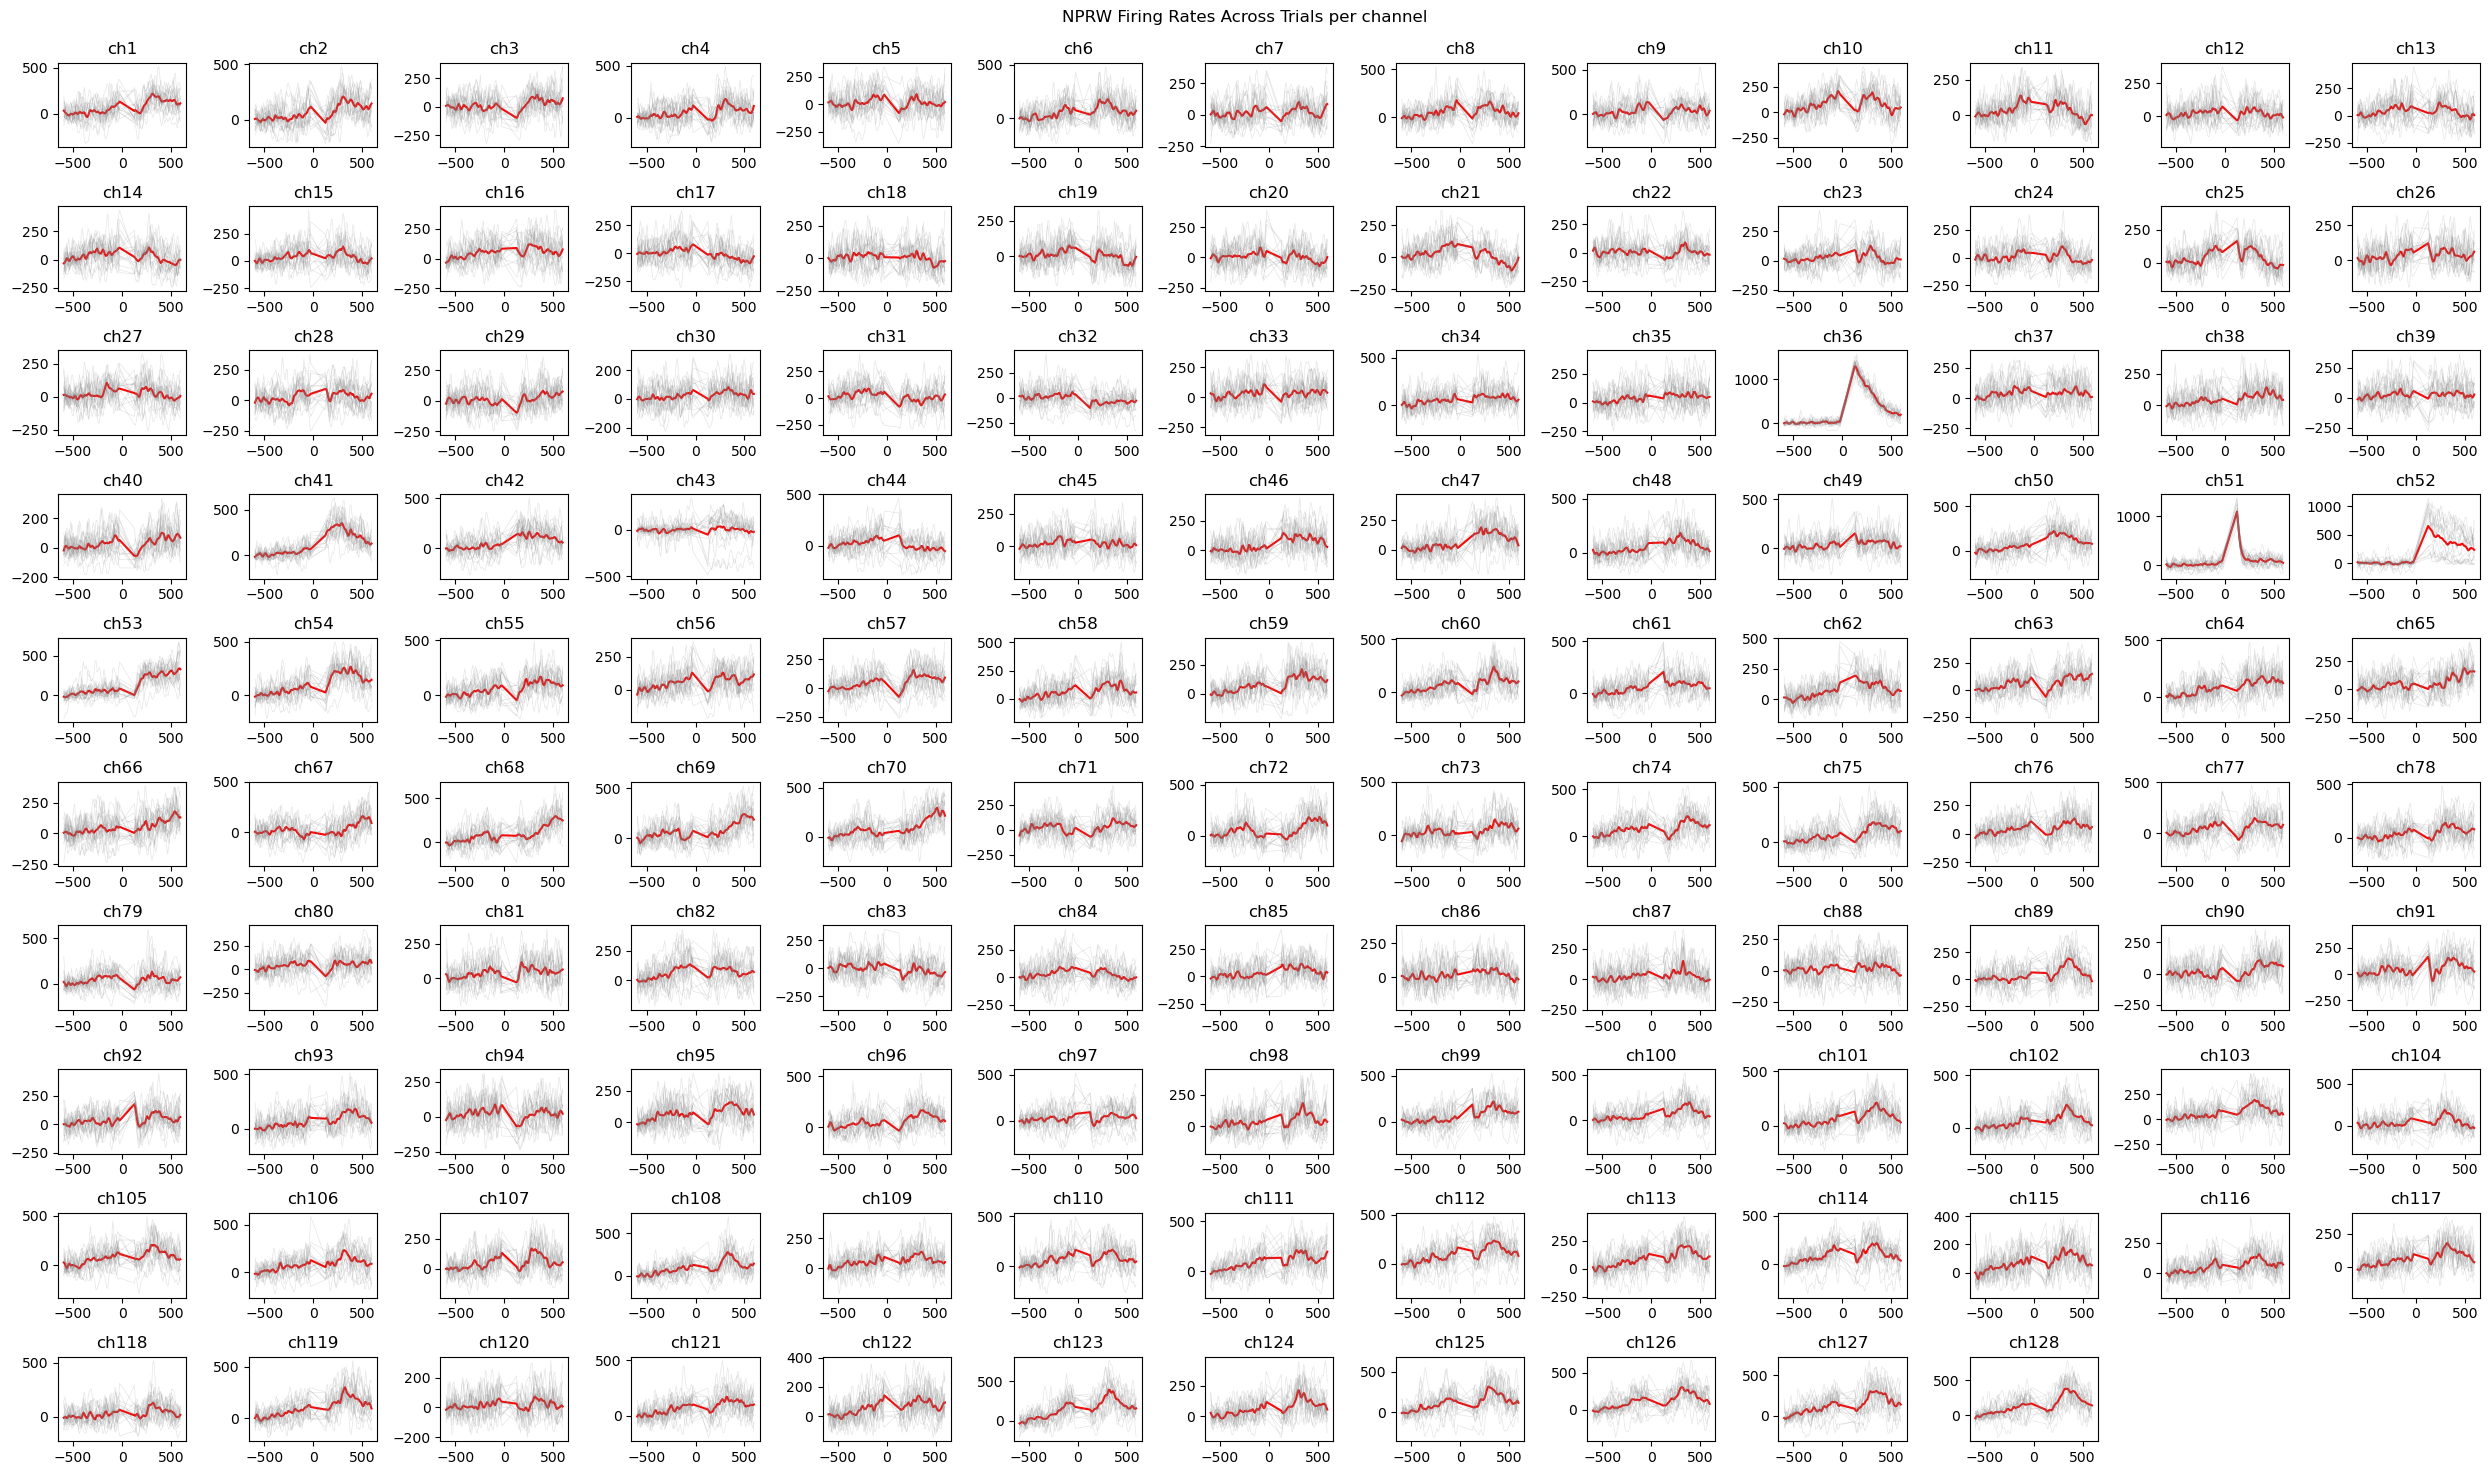

In [25]:
plt.figure(figsize=(25, 15))
for ch_select in range(128):
    plt.subplot(10,13, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(NPRW_rates_zeroed[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, NPRW_rates_zeroed[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.2)
    plt.title("ch" + str(ch_select + 1))
    
plt.suptitle("NPRW Firing Rates Across Trials per channel\n")
plt.tight_layout()

# NPRW_rates_zeroed.shape

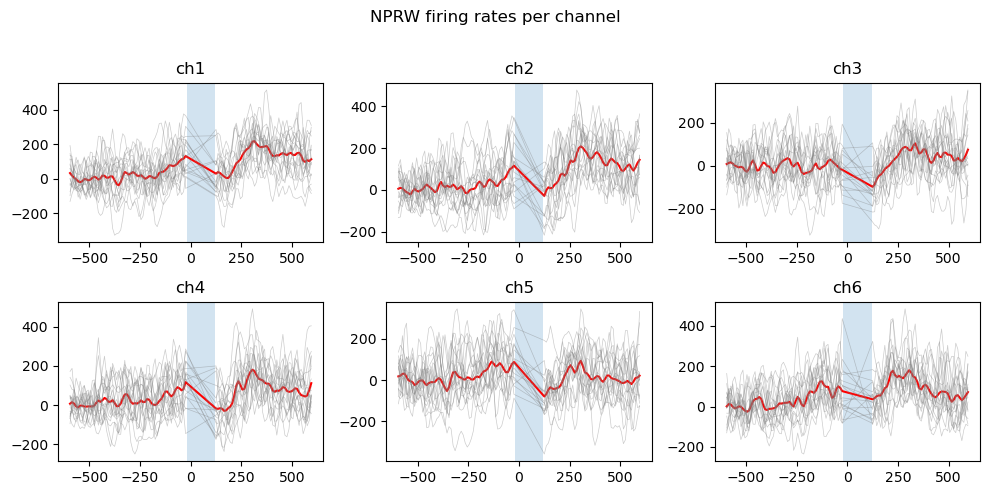

In [45]:
plt.figure(figsize=(10, 5))
for ch_select in range(6):
    ax = plt.subplot(2, 3, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(NPRW_rates_zeroed[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, NPRW_rates_zeroed[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.4)
    plt.title("ch" + str(ch_select + 1))
    ax.axvspan(-20, 120, alpha=0.2)
    
plt.suptitle("NPRW firing rates per channel\n")
plt.tight_layout()

In [ ]:
from sklearn.decomposition import PCA

X = np.transpose(NPRW_rates_zeroed, axes=(0, 2, 1))  # (n_trials, n_bins, n_ch)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

num_PCs = 20

n_trials, n_bins, n_ch = X.shape
n_comp = min(num_PCs, n_bins, n_ch)

# Preallocate latents over time for each trial, and explained variance
pcs_one_cond = np.zeros((n_trials, n_comp, n_bins), dtype=np.float32)
explained_var_one_cond = np.zeros((n_trials, n_comp), dtype=np.float32)

for trial in range(n_trials):
    # PCA for each trial
    X_trial = X[trial, :, :]  # (n_bins, n_ch)
    total_var_trial = np.var(X_trial, axis=0).sum() # Total variance over time, but summed over channels
    if n_comp >= 1 and total_var_trial > 0.0:
        pca = PCA(n_components=n_comp) # For consistency
        pcs_trial = pca.fit_transform(X_trial)  # (n_bins, n_comp)
        pcs_one_cond[trial] = pcs_trial.T.astype(np.float32)
        explained_var_one_cond[trial] = np.nan_to_num(
            pca.explained_variance_ratio_, nan=0.0)
    else:
        pcs_one_cond[trial] = 0.0
        explained_var_one_cond[trial] = 0.0

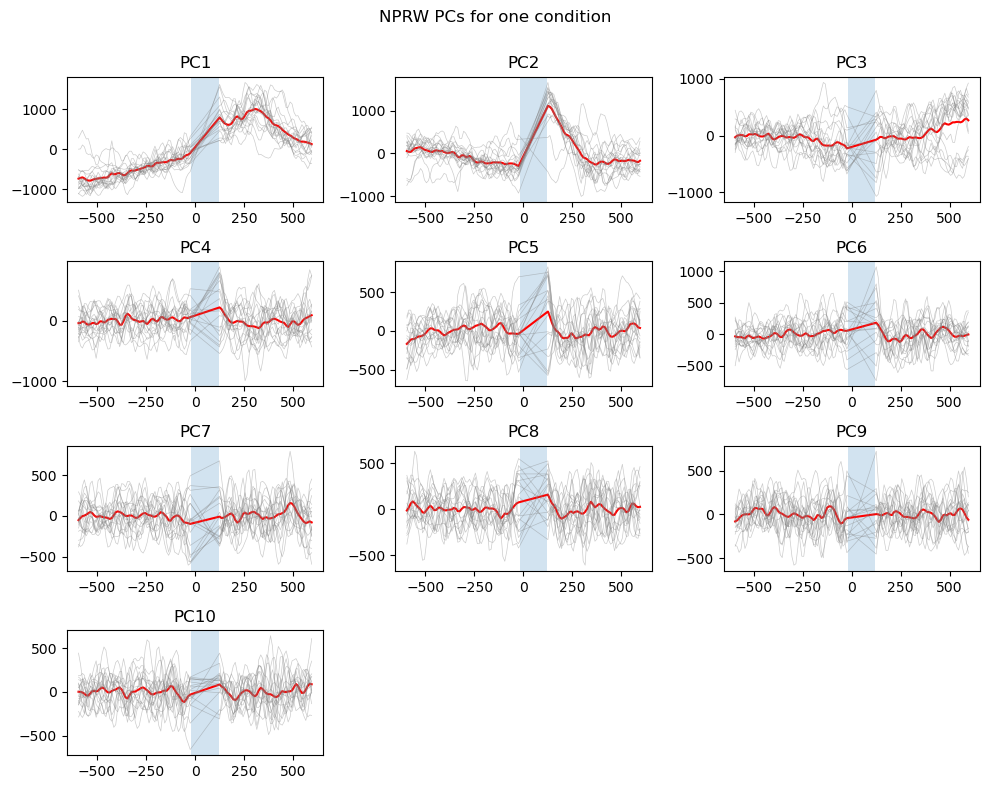

In [35]:
plt.figure(figsize=(10, 8))
for ch_select in range(10):
    ax = plt.subplot(4, 3, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(pcs_one_cond[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, pcs_one_cond[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.4)
    plt.title("PC" + str(ch_select + 1))
    ax.axvspan(-20, 120, alpha=0.2)
    
plt.suptitle("NPRW PCs for one condition\n")
plt.tight_layout()

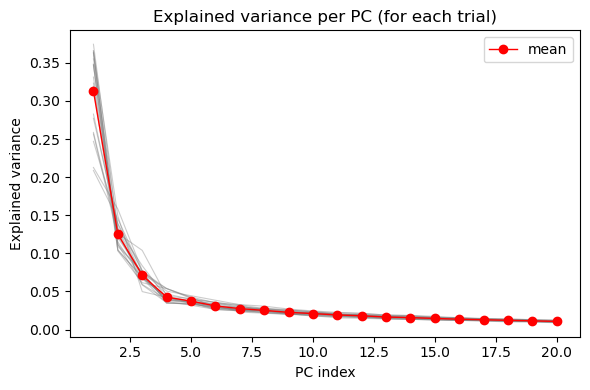

In [19]:
pc_idx = np.arange(1, num_PCs + 1)

plt.figure(figsize=(6, 4))
plt.plot(pc_idx, explained_var_one_cond.T, color="gray", alpha=0.4, linewidth=0.8) # individual trials
plt.plot(pc_idx, explained_var_one_cond.mean(axis=0), color="red", linewidth=1, marker="o", label="mean") # mean
plt.xlabel("PC index")
plt.ylabel("Explained variance")
plt.title("Explained variance per PC (for each trial)")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
from pathlib import Path
import re
import numpy as np

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
targets = ["Target_A", "Target_B"]

# BR ranges
br_list = list(range(3, 7)) + list(range(12, 25))

# regex to extract BR number
br_re = re.compile(r"__BR_(\d{3})_")
found_files = {}
for target in targets:
    target_dir = PERI_ROOT / target
    files = []

    for f in target_dir.glob("peristim__*.npz"):
        m = br_re.search(f.name)
        if m:
            br_num = int(m.group(1))
            if br_num in br_list:
                files.append(f)

    found_files[target] = sorted(files)
    
    
npz_path = PERI_ROOT / TARGET / FILES
peristim_npz = np.load(npz_path, allow_pickle=True)
NPRW_rates_zeroed = peristim_npz['NPRW_rates_zeroed']

In [21]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# --- load + keep provenance labels ---
NPRW_list = []
file_labels = []   # one label per trial (same length as axis 0 after concat)

for file_idx, f in enumerate(sorted(found_files["Target_A"])):
    with np.load(f, allow_pickle=True) as npz:
        arr = npz["NPRW_rates_zeroed"]          # shape (n_trials_in_file, ...)
    NPRW_list.append(arr)
    file_labels.extend([file_idx] * arr.shape[0])

NPRW_rates_zeroed_tA = np.concatenate(NPRW_list, axis=0)
file_labels = np.asarray(file_labels, dtype=int)

print("tA shape:", NPRW_rates_zeroed_tA.shape)
print("#files:", len(NPRW_list), "label shape:", file_labels.shape)
print("trials per file:", np.bincount(file_labels))


# Target B
NPRW_rates_zeroed_tB = []
for f in found_files["Target_B"]:
    with np.load(f, allow_pickle=True) as npz:
        NPRW_rates_zeroed_tB.append(npz["NPRW_rates_zeroed"])

NPRW_rates_zeroed_tB = np.concatenate(NPRW_rates_zeroed_tB, axis=0)

tA shape: (147, 128, 106)
#files: 15 label shape: (147,)
trials per file: [12  6 11  9  9 10 10 11 12  9  8  8  9 11 12]


In [22]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=0)
train_idx, test_idx = next(sss.split(np.zeros(len(file_labels)), file_labels))

X_train = NPRW_rates_zeroed_tA[train_idx]
X_test  = NPRW_rates_zeroed_tA[test_idx]

labels_train = file_labels[train_idx]
labels_test  = file_labels[test_idx]

print("train trials per file:", np.bincount(labels_train))
print("test trials per file: ", np.bincount(labels_test))


train trials per file: [8 4 8 6 6 7 7 8 8 6 6 6 6 8 8]
test trials per file:  [4 2 3 3 3 3 3 3 4 3 2 2 3 3 4]


In [23]:
NPRW_rates_zeroed_tA.shape

(147, 128, 106)

In [24]:
X_train.shape

(102, 128, 106)

In [25]:
X_test.shape

(45, 128, 106)

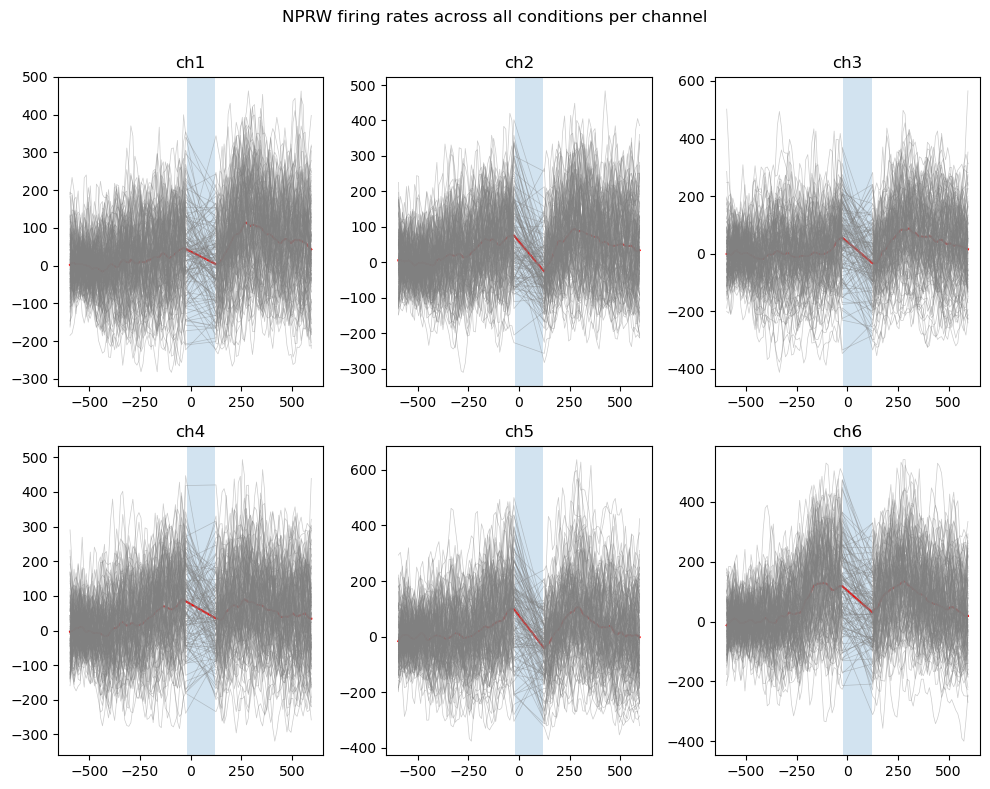

In [26]:
plt.figure(figsize=(10, 8))
for ch_select in range(6):
    ax = plt.subplot(2, 3, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(NPRW_rates_zeroed_tA[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, NPRW_rates_zeroed_tA[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.4)
    plt.title("ch" + str(ch_select + 1))
    ax.axvspan(-20, 120, alpha=0.2)
    
plt.suptitle("NPRW firing rates across all conditions per channel\n")
plt.tight_layout()

In [27]:
from sklearn.decomposition import PCA

X = np.transpose(NPRW_rates_zeroed_tA, axes=(0, 2, 1))  # (n_trials, n_bins, n_ch)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

num_PCs = 20
train_frac = 0.7

n_trials, n_bins, n_ch = X.shape
n_comp = min(num_PCs, n_bins, n_ch)

# Preallocate latents over time for each trial, and explained variance
pcs_all = np.zeros((n_trials, n_comp, n_bins), dtype=np.float32)
explained_var_all = np.zeros((n_trials, n_comp), dtype=np.float32)

mse_test = np.full(n_trials, np.nan, dtype=np.float32)

for trial in range(n_trials):
    # PCA for each trial
    X_trial = X[trial, :, :]  # (n_bins, n_ch)
    total_var_trial = np.var(X_trial, axis=0).sum() # Total variance over time, but summed over channels
    if n_comp >= 1 and total_var_trial > 0.0:
        pca = PCA(n_components=n_comp) # For consistency
        pcs_trial = pca.fit_transform(X_trial)  # (n_bins, n_comp)
        pcs_all[trial] = pcs_trial.T.astype(np.float32)
        explained_var_all[trial] = np.nan_to_num(
            pca.explained_variance_ratio_, nan=0.0)
    else:
        pcs_all[trial] = 0.0
        explained_var_all[trial] = 0.0

In [28]:
pcs_one_cond.shape

(19, 20, 106)

In [29]:

pcs_all.shape

(147, 20, 106)

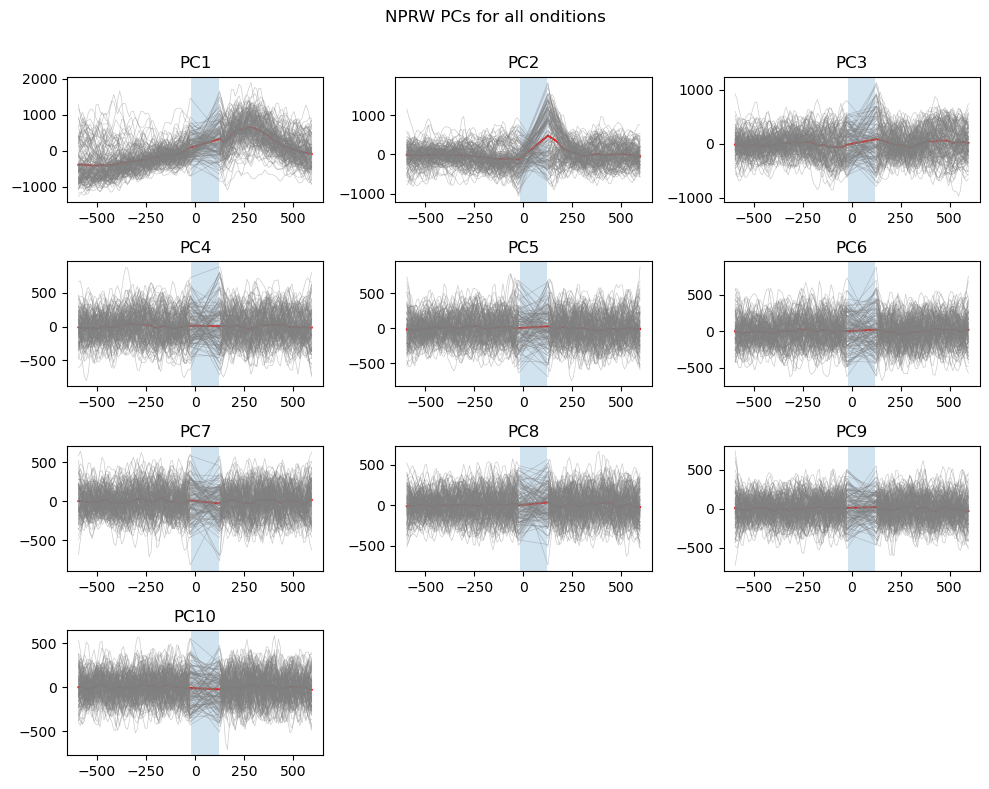

In [30]:
plt.figure(figsize=(10, 8))
for ch_select in range(10):
    ax = plt.subplot(4, 3, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(pcs_all[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, pcs_all[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.4)
    plt.title("PC" + str(ch_select + 1))
    ax.axvspan(-20, 120, alpha=0.2)
    
plt.suptitle("NPRW PCs for all onditions\n")
plt.tight_layout()

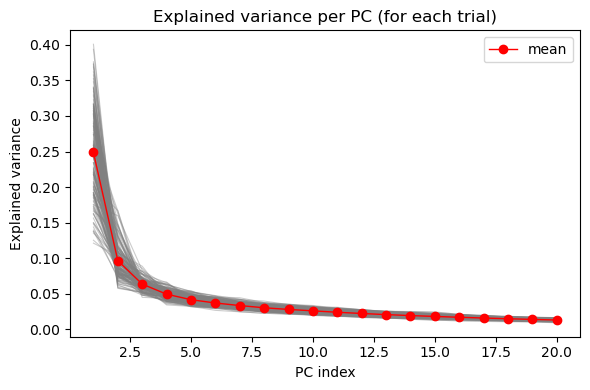

In [31]:
pc_idx = np.arange(1, num_PCs + 1)

plt.figure(figsize=(6, 4))
plt.plot(pc_idx, explained_var_all.T, color="gray", alpha=0.4, linewidth=0.8) # individual trials
plt.plot(pc_idx, explained_var_all.mean(axis=0), color="red", linewidth=1, marker="o", label="mean") # mean
plt.xlabel("PC index")
plt.ylabel("Explained variance")
plt.title("Explained variance per PC (for each trial)")
plt.legend()
plt.tight_layout()
plt.show()

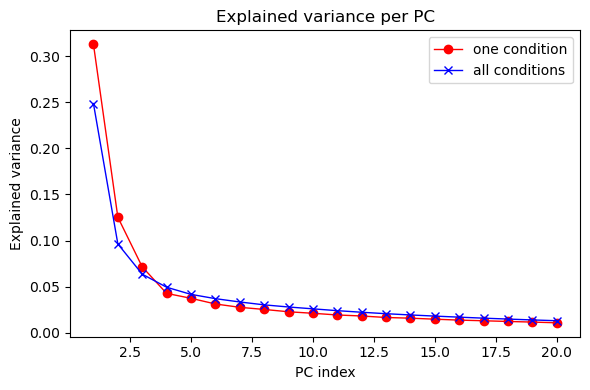

In [41]:
plt.figure(figsize=(6, 4))
plt.plot(pc_idx, explained_var_one_cond.mean(axis=0), color="red", linewidth=1, marker="o", label="one condition") # mean
plt.plot(pc_idx, explained_var_all.mean(axis=0), color="blue", linewidth=1, marker="x", label="all conditions") # mean
plt.xlabel("PC index")
plt.ylabel("Explained variance")
plt.title("Explained variance per PC")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
explained_var_all.shape

(19, 20)

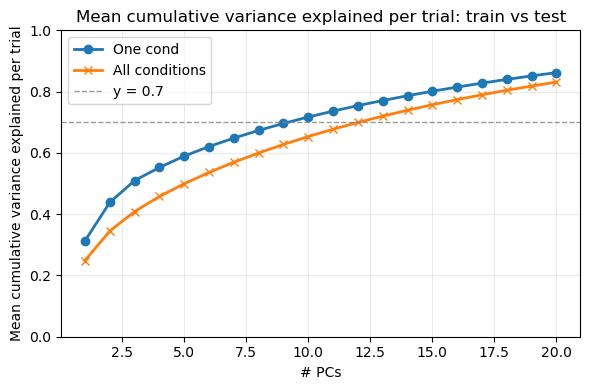

In [44]:
one_cond_cum = np.cumsum(explained_var_one_cond.mean(axis=0))
all_cond_cum = np.cumsum(explained_var_all.mean(axis=0))

plt.figure(figsize=(6, 4))
plt.plot(pc_idx, one_cond_cum, marker="o", linewidth=2, label="One cond")
plt.plot(pc_idx, all_cond_cum, marker="x", linewidth=2, label="All conditions")
plt.axhline(y=0.7, linestyle="--", color="gray", linewidth=1, alpha=0.8, label="y = 0.7")
plt.xlabel("# PCs")
plt.ylabel("Mean cumulative variance explained per trial")
plt.title("Mean cumulative variance explained per trial: train vs test")
plt.ylim(0, 1)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
num_PCs = 30
n_trials, n_bins, n_ch = X.shape
max_k = min(num_PCs, n_bins, n_ch)

X_train_flat = X[train_idx].reshape(-1, n_ch)
pca = PCA(n_components=max_k, random_state=0)
pca.fit(X_train_flat)

X_test_flat = X[test_idx].reshape(-1, n_ch)

Xc = X_test_flat - X_test_flat.mean(axis=0, keepdims=True) # Zero out test data
sst = np.sum(Xc ** 2) # normalization constant / total sum of squares

Z_full = pca.transform(X_test_flat)  # project test data onto PCs (bins times trials, n_components)
test_r2 = np.zeros(max_k, dtype=float)

for k in range(1, max_k + 1):
    X_hat = Z_full[:, :k] @ pca.components_[:k, :] + pca.mean_      # reconstruct test data using first k PCs
    sse = np.sum((X_test_flat - X_hat) ** 2)                        # sum of squared errors
    test_r2[k - 1] = 0.0 if sst == 0 else (1.0 - sse / sst)         # explained variance


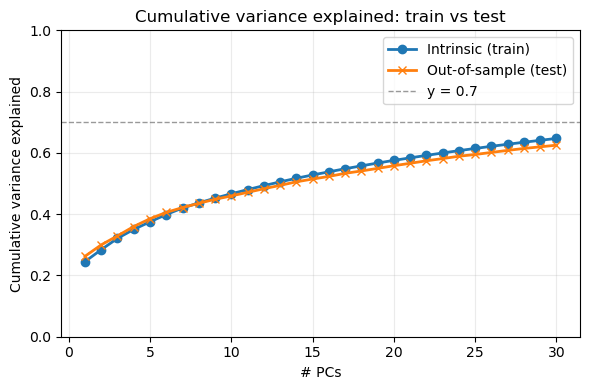

In [ ]:
k = np.arange(1, max_k + 1)

train_cum = np.cumsum(pca.explained_variance_ratio_[:max_k])
test_cum = test_r2

plt.figure(figsize=(6, 4))
plt.plot(k, train_cum, marker="o", linewidth=2, label="Intrinsic (train)")
plt.plot(k, test_cum, marker="x", linewidth=2, label="Out-of-sample (test)")
plt.axhline(y=0.7, linestyle="--", color="gray", linewidth=1, alpha=0.8, label="y = 0.7")
plt.xlabel("# PCs")
plt.ylabel("Cumulative variance explained")
plt.title("Cumulative variance explained: train vs test")
plt.ylim(0, 1)
plt.grid(True, alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()
